<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/AlexNet_on_CIFAR_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [3]:
print("Tensorflow Version_",tf.__version__)

Tensorflow Version_ 2.20.0


In [4]:
(X_train, y_train),(X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [6]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

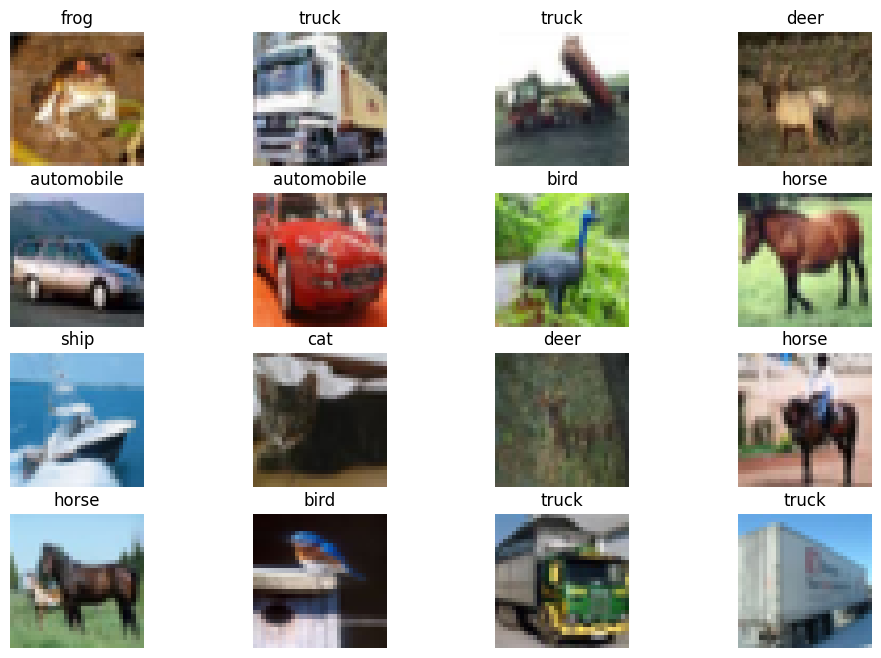

In [7]:
plt.figure(figsize=(12,8))
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')

plt.show()

In [8]:
X_train = X_train/255.0
X_test = X_test/255.0

In [9]:
IMG_SIZE=64

X_train_resized = tf.image.resize(X_train,(IMG_SIZE,IMG_SIZE))
X_test_resized = tf.image.resize(X_test,(IMG_SIZE,IMG_SIZE))

In [10]:
print(X_train_resized.shape)

(50000, 64, 64, 3)


In [11]:
#AlexNet became famous partly because of augmentation.

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [18]:
AlexNet = models.Sequential()

# Layer 1

AlexNet.add(
    layers.Conv2D(
        filters=96,
        kernel_size=(11,11),
        strides=(4,4),
        padding='same',
        activation='relu',
        input_shape=(64,64,3)
    )
)

AlexNet.add(
    layers.MaxPooling2D(
        pool_size=(3,3),
        strides=(2,2)
    )
)

# Layer 2

AlexNet.add(
    layers.Conv2D(
        filters=256,
        kernel_size=(5,5),
        padding='same',
        activation='relu'
    )
)

AlexNet.add(
    layers.MaxPooling2D(
        pool_size=(3,3),
        strides=(2,2)
    )
)

# Layer 3

AlexNet.add(
    layers.Conv2D(
        filters=384,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    )
)

# Layer 4

AlexNet.add(
    layers.Conv2D(
        filters=384,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    )
)

# Layer 5

AlexNet.add(
    layers.Conv2D(
        filters=256,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    )
)

AlexNet.add(
    layers.MaxPooling2D(
        pool_size=(3,3),
        strides=(2,2)
    )
)

# Flatten

AlexNet.add(
    layers.Flatten()
)

# Fully Connected Layer

AlexNet.add(
    layers.Dense(
        1024,
        activation='relu'
    )
)

AlexNet.add(
    layers.Dropout(0.5)
)

AlexNet.add(
    layers.Dense(
        512,
        activation='relu'
    )
)

AlexNet.add(
    layers.Dropout(0.5)
)

AlexNet.add(
    layers.Dense(
        10,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
AlexNet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,540,298 (17.32 MB)

 Trainable params: 4,540,298 (17.32 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
AlexNet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [23]:
history = AlexNet.fit(

    X_train_resized,

    y_train,

    epochs=15,

    batch_size=64,

    validation_split=0.2,

    callbacks=[early_stop]
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 623s 996ms/step - accuracy: 0.1005 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3028
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 607s 971ms/step - accuracy: 0.0998 - loss: 2.3027 - val_accuracy: 0.0980 - val_loss: 2.3028
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 605s 968ms/step - accuracy: 0.0981 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3029


In [24]:
test_loss, test_acc = AlexNet.evaluate(
    X_test_resized,
    y_test
)

print("Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.1000 - loss: 2.3026
Accuracy: 0.10000000149011612


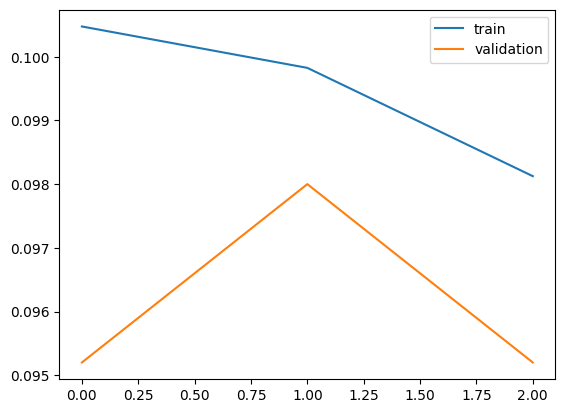

In [25]:
plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.legend()

plt.show()